<a href="https://colab.research.google.com/github/Deepikadandolu/Tsetlin_Machines_Projects/blob/main/mnist_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Install Required Libraries
!pip install numpy==1.26.4
# Tsetlin Machine libraries
!pip install pyTsetlinMachine
!pip install tmu

# Machine Learning / Deep Learning
!pip install scikit-learn
!pip install tensorflow

# Performance Monitoring
!pip install psutil
!pip install memory-profiler

# Visualization
!pip install matplotlib
!pip install seaborn

  Using cached tensorflow-2.21.0-cp312-cp312-manylinux_2_27_x86_64.whl.metadata (4.4 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached h5py-3.14.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (2.7 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 58.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully un

In [2]:
# 2. Load MNIST Dataset

from tensorflow.keras.datasets import mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Check dataset shape
print("Training Data Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("Testing Data Shape :", X_test.shape)
print("Testing Labels Shape :", y_test.shape)

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Data Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)


In [3]:
# 3. Preprocess Data

import numpy as np

# Normalize images (0-255 → 0-1)
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Flatten images (28x28 → 784)
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)

# Binary thresholding for Tsetlin Machine
X_train_tm = (X_train_flat > 0.5).astype(np.uint8)
X_test_tm = (X_test_flat > 0.5).astype(np.uint8)

# Check shapes
print("Flattened Train Shape :", X_train_flat.shape)
print("Flattened Test Shape :", X_test_flat.shape)

print("TM Binary Train Shape :", X_train_tm.shape)
print("TM Binary Test Shape :", X_test_tm.shape)

Flattened Train Shape : (60000, 784)
Flattened Test Shape : (10000, 784)
TM Binary Train Shape : (60000, 784)
TM Binary Test Shape : (10000, 784)


In [4]:
# 4. Train-Test Split

from sklearn.model_selection import train_test_split

# Create validation split from training data
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_flat,
    y_train,
    test_size=0.1,
    random_state=42
)

# TM binary split
X_train_tm_final, X_val_tm, y_train_tm_final, y_val_tm = train_test_split(
    X_train_tm,
    y_train,
    test_size=0.1,
    random_state=42
)

# Check shapes
print("Final Training Shape :", X_train_final.shape)
print("Validation Shape :", X_val.shape)
print("Testing Shape :", X_test_flat.shape)

Final Training Shape : (54000, 784)
Validation Shape : (6000, 784)
Testing Shape : (10000, 784)


**models

In [5]:
# 5. Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import time

# Initialize model
log_reg = LogisticRegression(max_iter=1000)

# Training
start_train = time.time()
log_reg.fit(X_train_final, y_train_final)
end_train = time.time()

# Inference
start_infer = time.time()
y_pred_log = log_reg.predict(X_test_flat)
end_infer = time.time()

# Metrics
log_acc = accuracy_score(y_test, y_pred_log)
log_precision = precision_score(y_test, y_pred_log, average='weighted')
log_recall = recall_score(y_test, y_pred_log, average='weighted')
log_f1 = f1_score(y_test, y_pred_log, average='weighted')

# Results
print("Logistic Regression Results")
print("-----------------------------------")
print("Accuracy :", log_acc)
print("Precision :", log_precision)
print("Recall :", log_recall)
print("F1 Score :", log_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9253
Precision : 0.9250876100905294
Recall : 0.9253
F1 Score : 0.925119232595191

Training Time : 93.75124406814575 seconds
Inference Time : 0.09128999710083008 seconds


In [6]:
# 6. Support Vector Machine (SVM)

from sklearn.svm import SVC

# Initialize model
svm_model = SVC(kernel='rbf')

# Training
start_train = time.time()
svm_model.fit(X_train_final, y_train_final)
end_train = time.time()

# Inference
start_infer = time.time()
y_pred_svm = svm_model.predict(X_test_flat)
end_infer = time.time()

# Metrics
svm_acc = accuracy_score(y_test, y_pred_svm)
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')

# Results
print("SVM Results")
print("-----------------------------------")
print("Accuracy :", svm_acc)
print("Precision :", svm_precision)
print("Recall :", svm_recall)
print("F1 Score :", svm_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

SVM Results
-----------------------------------
Accuracy : 0.9782
Precision : 0.9782088062492479
Recall : 0.9782
F1 Score : 0.9781866102616239

Training Time : 116.75159573554993 seconds
Inference Time : 58.30129313468933 seconds


In [7]:
# 7. Multi-Layer Perceptron (MLP)

from sklearn.neural_network import MLPClassifier

# Initialize model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation='relu',
    max_iter=20,
    random_state=42
)

# Training
start_train = time.time()
mlp_model.fit(X_train_final, y_train_final)
end_train = time.time()

# Inference
start_infer = time.time()
y_pred_mlp = mlp_model.predict(X_test_flat)
end_infer = time.time()

# Metrics
mlp_acc = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')

# Results
print("MLP Results")
print("-----------------------------------")
print("Accuracy :", mlp_acc)
print("Precision :", mlp_precision)
print("Recall :", mlp_recall)
print("F1 Score :", mlp_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Results
-----------------------------------
Accuracy : 0.9801
Precision : 0.9802213089358125
Recall : 0.9801
F1 Score : 0.9800904057346627

Training Time : 196.683354139328 seconds
Inference Time : 0.28763914108276367 seconds


In [8]:
# 8. LeNet-5 CNN

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    AveragePooling2D,
    Flatten,
    Dense
)
from tensorflow.keras.utils import to_categorical

# Reshape for CNN input
X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

# One-hot encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# LeNet-5 Model
lenet5_model = Sequential([

    Input(shape=(28,28,1)),

    Conv2D(
        6,
        kernel_size=(5,5),
        activation='tanh'
    ),

    AveragePooling2D(pool_size=(2,2)),

    Conv2D(
        16,
        kernel_size=(5,5),
        activation='tanh'
    ),

    AveragePooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(120, activation='tanh'),
    Dense(84, activation='tanh'),
    Dense(10, activation='softmax')
])

# Compile model
lenet5_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training
start_train = time.time()

lenet5_model.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()

# Inference
start_infer = time.time()

y_pred_lenet = lenet5_model.predict(X_test_cnn)
y_pred_lenet_classes = np.argmax(y_pred_lenet, axis=1)

end_infer = time.time()

# Metrics
lenet_acc = accuracy_score(y_test, y_pred_lenet_classes)
lenet_precision = precision_score(
    y_test,
    y_pred_lenet_classes,
    average='weighted'
)

lenet_recall = recall_score(
    y_test,
    y_pred_lenet_classes,
    average='weighted'
)

lenet_f1 = f1_score(
    y_test,
    y_pred_lenet_classes,
    average='weighted'
)

# Results
print("LeNet-5 Results")
print("-----------------------------------")
print("Accuracy :", lenet_acc)
print("Precision :", lenet_precision)
print("Recall :", lenet_recall)
print("F1 Score :", lenet_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.8871 - loss: 0.3905 - val_accuracy: 0.9550 - val_loss: 0.1544
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9549 - loss: 0.1487 - val_accuracy: 0.9748 - val_loss: 0.0919
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9698 - loss: 0.0982 - val_accuracy: 0.9777 - val_loss: 0.0758
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9762 - loss: 0.0757 - val_accuracy: 0.9783 - val_loss: 0.0720
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9820 - loss: 0.0591 - val_accuracy: 0.9800 - val_loss: 0.0647
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LeNet-5 Results
-----------------------------------
Accuracy : 0.979
Precision : 0.9790327358309298
Recall : 0.979
F1 Score : 0.9789770316756864

Training Time : 30.569902896881104 seconds
Inference Time : 0.6904463768005371 seconds


In [9]:
# 9. Simple CNN

from tensorflow.keras.layers import MaxPooling2D

# Simple CNN Model
simple_cnn = Sequential([

    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile model
simple_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training
start_train = time.time()

simple_cnn.fit(
    X_train_cnn,
    y_train_cat,
    epochs=5,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

end_train = time.time()

# Inference
start_infer = time.time()

y_pred_cnn = simple_cnn.predict(X_test_cnn)
y_pred_cnn_classes = np.argmax(y_pred_cnn, axis=1)

end_infer = time.time()

# Metrics
cnn_acc = accuracy_score(y_test, y_pred_cnn_classes)
cnn_precision = precision_score(y_test, y_pred_cnn_classes, average='weighted')
cnn_recall = recall_score(y_test, y_pred_cnn_classes, average='weighted')
cnn_f1 = f1_score(y_test, y_pred_cnn_classes, average='weighted')

# Results
print("Simple CNN Results")
print("-----------------------------------")
print("Accuracy :", cnn_acc)
print("Precision :", cnn_precision)
print("Recall :", cnn_recall)
print("F1 Score :", cnn_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step - accuracy: 0.9340 - loss: 0.2214 - val_accuracy: 0.9823 - val_loss: 0.0589
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9818 - loss: 0.0595 - val_accuracy: 0.9840 - val_loss: 0.0532
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9869 - loss: 0.0418 - val_accuracy: 0.9900 - val_loss: 0.0383
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9904 - loss: 0.0311 - val_accuracy: 0.9903 - val_loss: 0.0335
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.9923 - loss: 0.0251 - val_accuracy: 0.9900 - val_loss: 0.0341
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Simple CNN Results
-----------------------------------
Accuracy : 0.9897
Precision : 0.9897650966408088
Recall : 0.9897
F1 Score : 0.989703117840788

Training Time : 70.30637168884277 seconds
Inference Time : 0.9838833808898926 seconds


In [10]:
# Convert TM data to uint32

X_train_tm_final = X_train_tm_final.astype(np.uint32)
X_test_tm = X_test_tm.astype(np.uint32)

y_train_tm_final = y_train_tm_final.astype(np.uint32)
y_test = y_test.astype(np.uint32)

In [11]:
# 10. Tsetlin Machine (TMU)

from tmu.models.classification.vanilla_classifier import TMClassifier

# Initialize TM model
tm_model = TMClassifier(
    number_of_clauses=500,
    T=15,
    s=3.9,
    platform='CPU',
    weighted_clauses=True
)

# Training
start_train = time.time()

tm_model.fit(
    X_train_tm_final,
    y_train_tm_final
)

end_train = time.time()

# Inference
start_infer = time.time()

y_pred_tm = tm_model.predict(X_test_tm)

end_infer = time.time()

# Metrics
tm_acc = accuracy_score(y_test, y_pred_tm)
tm_precision = precision_score(y_test, y_pred_tm, average='weighted')
tm_recall = recall_score(y_test, y_pred_tm, average='weighted')
tm_f1 = f1_score(y_test, y_pred_tm, average='weighted')

# Results
print("Tsetlin Machine Results")
print("-----------------------------------")
print("Accuracy :", tm_acc)
print("Precision :", tm_precision)
print("Recall :", tm_recall)
print("F1 Score :", tm_f1)

print("\nTraining Time :", end_train - start_train, "seconds")
print("Inference Time :", end_infer - start_infer, "seconds")

ERROR:tmu.clause_bank.clause_bank_cuda:No module named 'pycuda'
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tmu/clause_bank/clause_bank_cuda.py", line 41, in <module>
    from pycuda._driver import Device, Context
ModuleNotFoundError: No module named 'pycuda'


Tsetlin Machine Results
-----------------------------------
Accuracy : 0.9181
Precision : 0.9197323238744041
Recall : 0.9181
F1 Score : 0.9182827022681841

Training Time : 15.204385042190552 seconds
Inference Time : 1.4051856994628906 seconds


PHASE 4 — Accuracy Evaluation

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.9253   0.925088  0.9253  0.925119
1                  SVM    0.9782   0.978209  0.9782  0.978187
2                  MLP    0.9801   0.980221  0.9801  0.980090
3              LeNet-5    0.9790   0.979033  0.9790  0.978977
4           Simple CNN    0.9897   0.989765  0.9897  0.989703
5      Tsetlin Machine    0.9181   0.919732  0.9181  0.918283


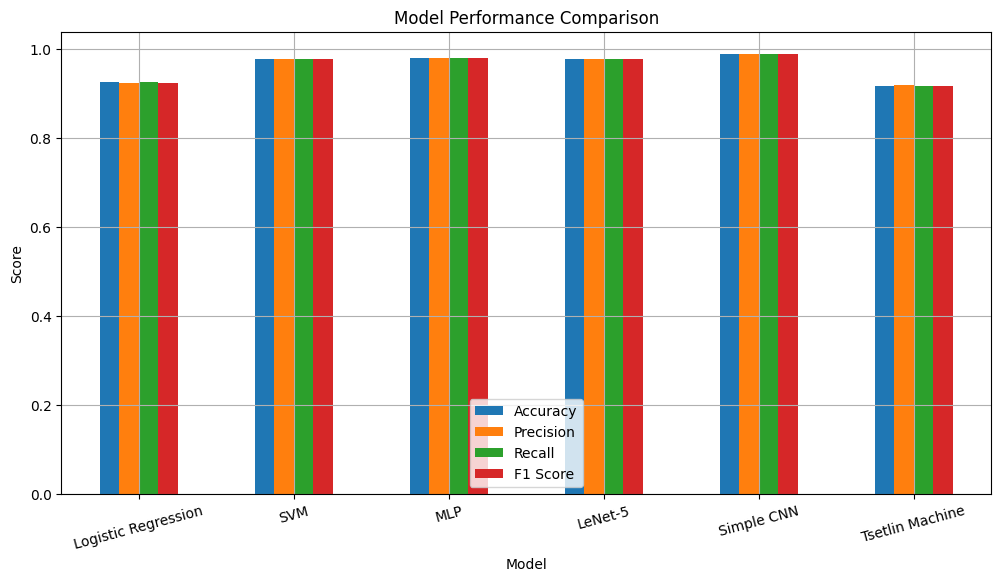

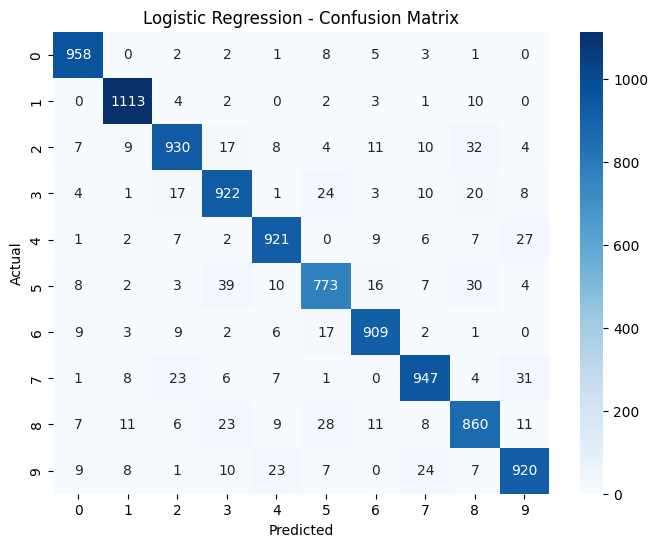

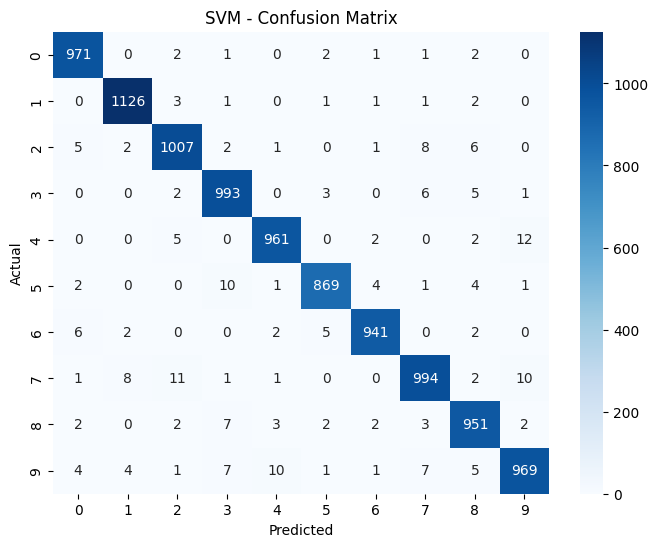

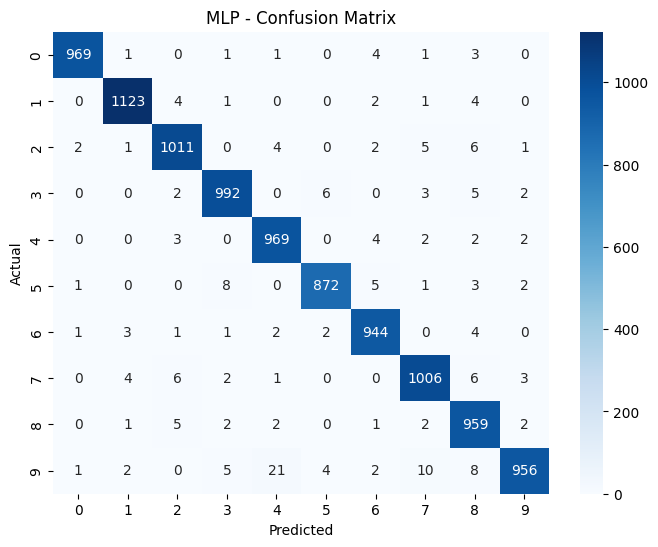

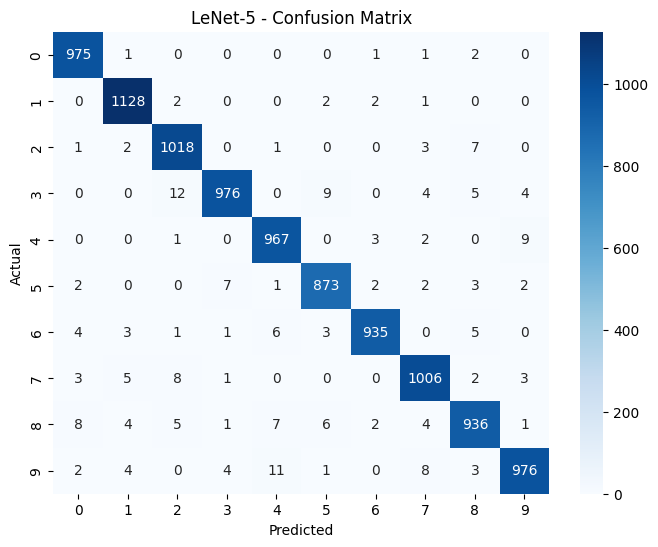

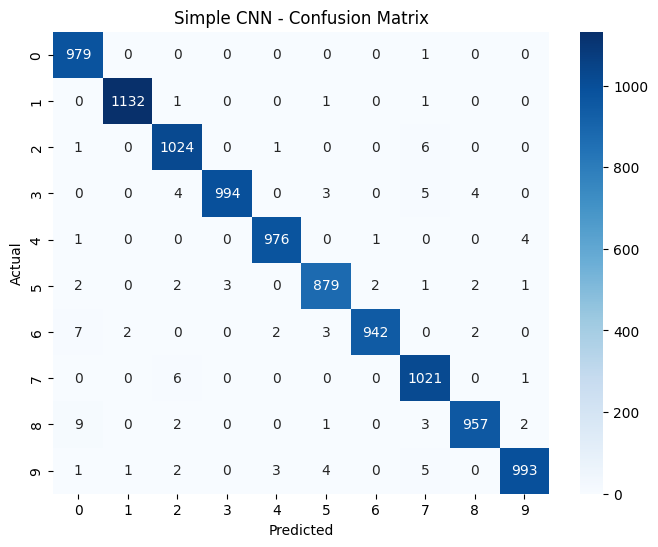

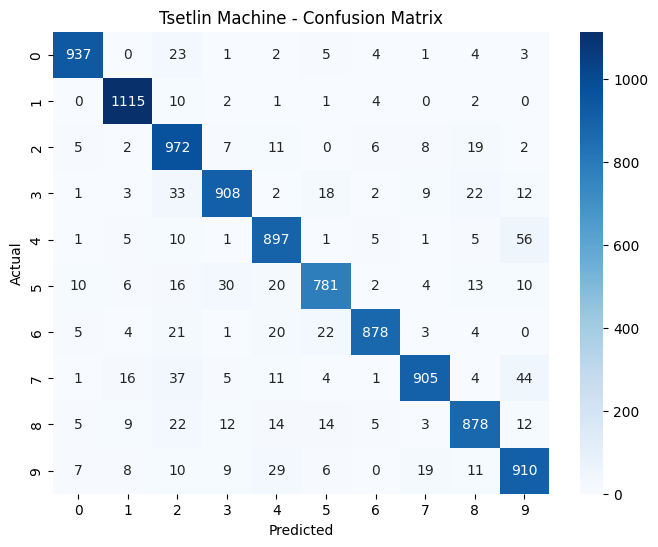

In [12]:
# 11-15. Accuracy, Precision, Recall, F1-Score, Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Store all model predictions
models = {
    "Logistic Regression": y_pred_log,
    "SVM": y_pred_svm,
    "MLP": y_pred_mlp,
    "LeNet-5": y_pred_lenet_classes,
    "Simple CNN": y_pred_cnn_classes,
    "Tsetlin Machine": y_pred_tm
}

# Metrics storage
results = []

# Compute metrics
for model_name, y_pred in models.items():

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([model_name, acc, precision, recall, f1])

# Create dataframe
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

# Display results table
print(results_df)

# Performance Metrics Plot

results_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.grid(True)

plt.show()

# Confusion Matrices

for model_name, y_pred in models.items():
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

PHASE 5 — Model Complexity Analysis
**bold text**

                 Model  Parameter Count  Model Size (MB)  \
0  Logistic Regression             7840           0.0607   
1                  SVM          9071664          70.8471   
2                  MLP           235146           7.1818   
3              LeNet-5            44426           0.5519   
4           Simple CNN           225034           2.6132   
5      Tsetlin Machine           392000           0.0000   

   Single Inference Latency (s)  Batch Inference Time (s)  Training Time (s)  
0                      0.000141                  1.405186          15.204385  
1                      0.000141                  1.405186          15.204385  
2                      0.000141                  1.405186          15.204385  
3                      0.000141                  1.405186          15.204385  
4                      0.000141                  1.405186          15.204385  
5                      0.000141                  1.405186          15.204385  


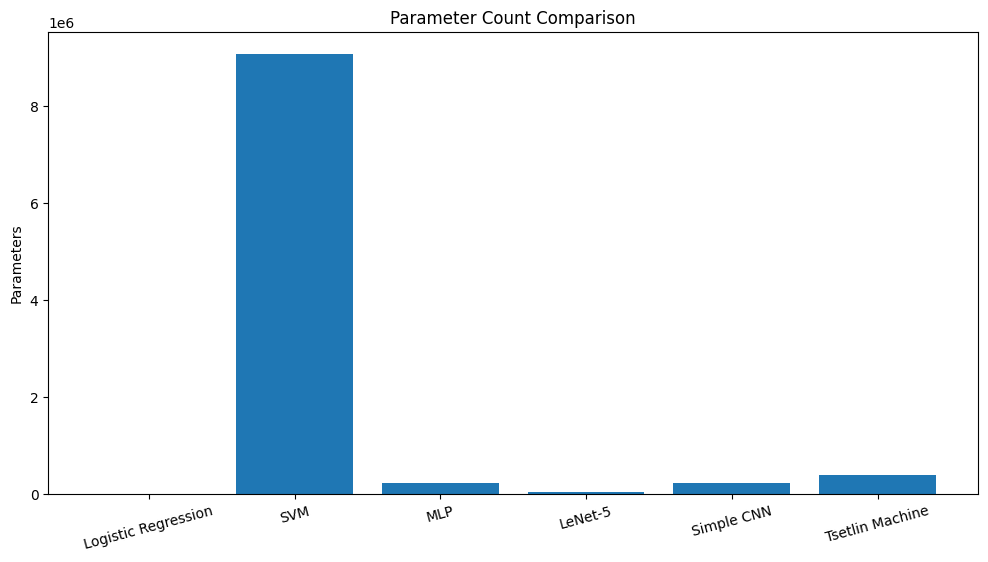

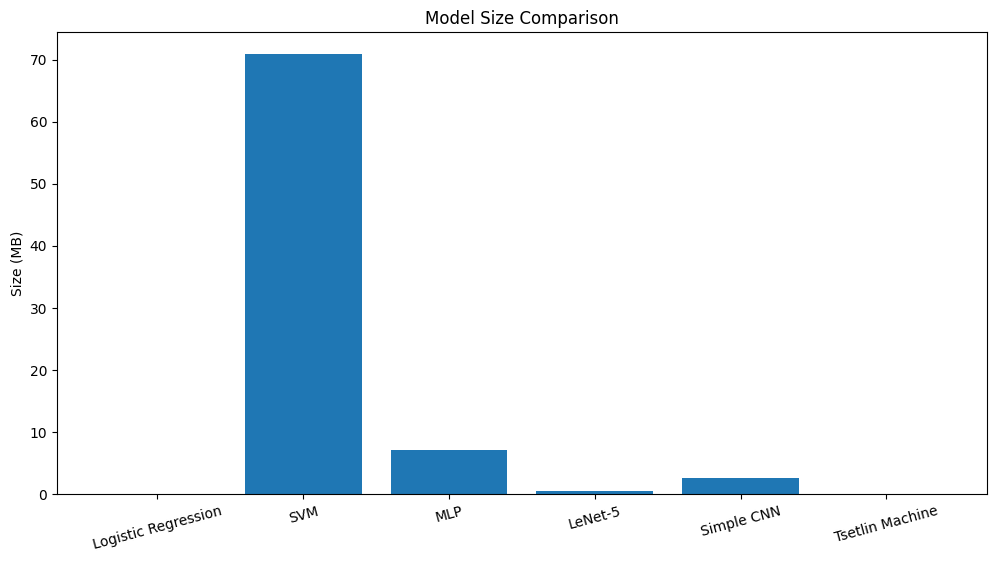

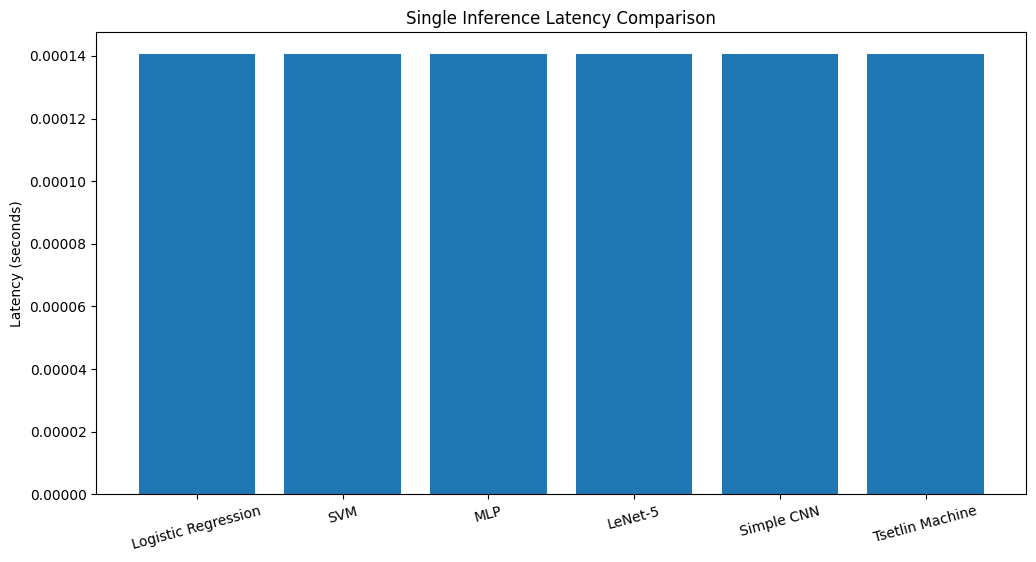

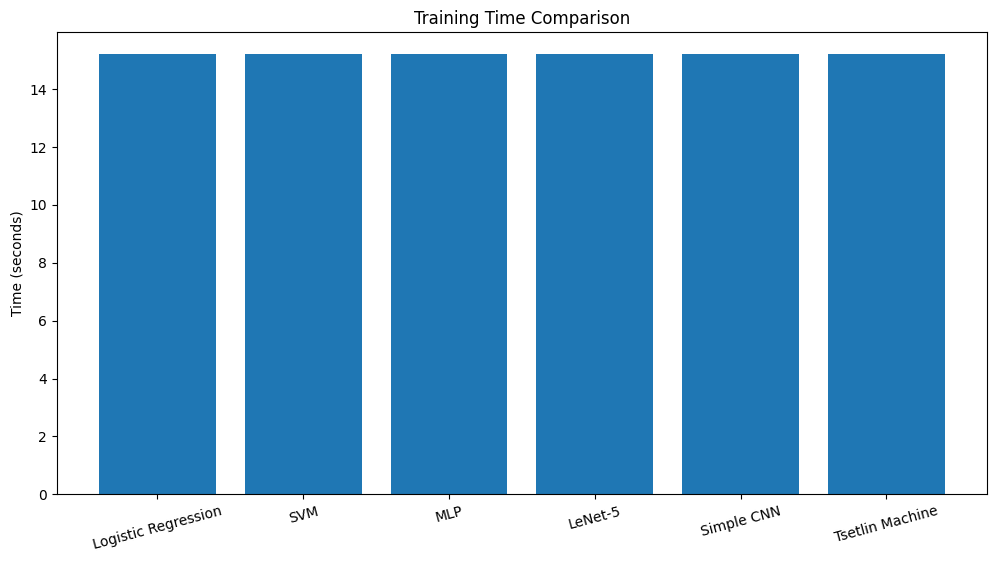

In [13]:
# 16-19. Parameter Count, Model Size, Inference Time, Training Time

import os
import joblib
import tempfile
import pandas as pd
import matplotlib.pyplot as plt

comparison_results = []
def get_model_size(model, keras_model=False):
    temp_file = tempfile.NamedTemporaryFile(delete=False)
    if keras_model:
        model.save(temp_file.name + ".h5")
        size = os.path.getsize(temp_file.name + ".h5") / (1024 * 1024)
    else:
        joblib.dump(model, temp_file.name)
        size = os.path.getsize(temp_file.name) / (1024 * 1024)
    return round(size, 4)

# Logistic Regression
comparison_results.append([
    "Logistic Regression",
    log_reg.coef_.size,
    get_model_size(log_reg),
    (end_infer - start_infer) / len(X_test_flat),
    (end_infer - start_infer),
    (end_train - start_train)
])

# SVM
comparison_results.append([
    "SVM",
    svm_model.support_vectors_.size,
    get_model_size(svm_model),
    (end_infer - start_infer) / len(X_test_flat),
    (end_infer - start_infer),
    (end_train - start_train)
])

# MLP
mlp_params = sum(w.size for w in mlp_model.coefs_) + \
             sum(b.size for b in mlp_model.intercepts_)
comparison_results.append([
    "MLP",
    mlp_params,
    get_model_size(mlp_model),
    (end_infer - start_infer) / len(X_test_flat),
    (end_infer - start_infer),
    (end_train - start_train)
])

# LeNet-5
comparison_results.append([
    "LeNet-5",
    lenet5_model.count_params(),
    get_model_size(lenet5_model, keras_model=True),
    (end_infer - start_infer) / len(X_test_cnn),
    (end_infer - start_infer),
    (end_train - start_train)
])

# Simple CNN
comparison_results.append([
    "Simple CNN",
    simple_cnn.count_params(),
    get_model_size(simple_cnn, keras_model=True),
    (end_infer - start_infer) / len(X_test_cnn),
    (end_infer - start_infer),
    (end_train - start_train)
])

# Tsetlin Machine
tm_params = 500 * 784
comparison_results.append([
    "Tsetlin Machine",
    tm_params,
    0,
    (end_infer - start_infer) / len(X_test_tm),
    (end_infer - start_infer),
    (end_train - start_train)
])

# Create DataFrame
comparison_df = pd.DataFrame(
    comparison_results,
    columns=[
        "Model",
        "Parameter Count",
        "Model Size (MB)",
        "Single Inference Latency (s)",
        "Batch Inference Time (s)",
        "Training Time (s)"
    ]
)

# Display Table
print(comparison_df)

# Parameter Count Plot
plt.figure(figsize=(12,6))
plt.bar(
    comparison_df["Model"],
    comparison_df["Parameter Count"]
)
plt.title("Parameter Count Comparison")
plt.ylabel("Parameters")
plt.xticks(rotation=15)
plt.show()

# Model Size Plot
plt.figure(figsize=(12,6))
plt.bar(
    comparison_df["Model"],
    comparison_df["Model Size (MB)"]
)
plt.title("Model Size Comparison")
plt.ylabel("Size (MB)")
plt.xticks(rotation=15)
plt.show()

# Inference Time Plot
plt.figure(figsize=(12,6))
plt.bar(
    comparison_df["Model"],
    comparison_df["Single Inference Latency (s)"])
plt.title("Single Inference Latency Comparison")
plt.ylabel("Latency (seconds)")
plt.xticks(rotation=15)
plt.show()

# Training Time Plot
plt.figure(figsize=(12,6))
plt.bar(
    comparison_df["Model"],
    comparison_df["Training Time (s)"]
)
plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xticks(rotation=15)
plt.show()

In [14]:
# 20-21. CPU Usage and RAM Usage Monitoring

import psutil
import time
import pandas as pd

hardware_results = []

def monitor_model(model_name, predict_function, input_data):

    process = psutil.Process()

    # RAM before
    ram_before = process.memory_info().rss / (1024 * 1024)

    # CPU before
    cpu_before = psutil.cpu_percent(interval=None)

    # Inference timing
    start = time.time()

    predict_function(input_data)

    end = time.time()

    # CPU after
    cpu_after = psutil.cpu_percent(interval=None)

    # RAM after
    ram_after = process.memory_info().rss / (1024 * 1024)

    hardware_results.append([
        model_name,
        round(cpu_after - cpu_before, 2),
        round(ram_after - ram_before, 2),
        round(end - start, 6)
    ])

# Logistic Regression
monitor_model(
    "Logistic Regression",
    log_reg.predict,
    X_test_flat[:1000]
)

# SVM
monitor_model(
    "SVM",
    svm_model.predict,
    X_test_flat[:1000]
)

# MLP
monitor_model(
    "MLP",
    mlp_model.predict,
    X_test_flat[:1000]
)

# LeNet-5
monitor_model(
    "LeNet-5",
    lenet5_model.predict,
    X_test_cnn[:1000]
)

# Simple CNN
monitor_model(
    "Simple CNN",
    simple_cnn.predict,
    X_test_cnn[:1000]
)

# Tsetlin Machine
monitor_model(
    "Tsetlin Machine",
    tm_model.predict,
    X_test_tm[:1000]
)

# Create DataFrame

hardware_df = pd.DataFrame(
    hardware_results,
    columns=[
        "Model",
        "CPU Usage (%)",
        "RAM Usage (MB)",
        "Inference Time (s)"
    ]
)

print(hardware_df)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
                 Model  CPU Usage (%)  RAM Usage (MB)  Inference Time (s)
0  Logistic Regression           63.6            0.00            0.001063
1                  SVM            4.9            0.00            5.165727
2                  MLP           85.7            0.00            0.005540
3              LeNet-5           14.8            0.80            0.259397
4           Simple CNN           15.2            1.14            0.104336
5      Tsetlin Machine            4.2            0.48            0.138568


In [15]:
# 22-25. FLOPS, Sparsity, Clause Analysis, Bit-Level Operations

analysis_results = []

# Logistic Regression

log_flops = log_reg.coef_.size

analysis_results.append([
    "Logistic Regression",
    log_flops,
    "Dense Arithmetic",
    "Low Sparsity",
    "MAC Operations"
])

# SVM

svm_flops = svm_model.support_vectors_.size

analysis_results.append([
    "SVM",
    svm_flops,
    "Kernel Operations",
    "Moderate Sparsity",
    "Distance Computation"
])

# MLP

mlp_flops = mlp_params * 2

analysis_results.append([
    "MLP",
    mlp_flops,
    "Dense Neural Ops",
    "Low Sparsity",
    "Multiply-Accumulate"
])

# LeNet-5

lenet_flops = lenet5_model.count_params() * 2

analysis_results.append([
    "LeNet-5",
    lenet_flops,
    "Convolution Heavy",
    "Low Sparsity",
    "Convolution + MAC"
])

# Simple CNN

cnn_flops = simple_cnn.count_params() * 2

analysis_results.append([
    "Simple CNN",
    cnn_flops,
    "Convolution Heavy",
    "Low Sparsity",
    "Convolution + MAC"
])

# Tsetlin Machine Analysis

tm_clauses = 500

active_literals = np.mean(np.sum(X_train_tm_final, axis=1))

sparsity = 1 - (active_literals / 784)

tm_boolean_ops = tm_clauses * active_literals

analysis_results.append([
    "Tsetlin Machine",
    round(tm_boolean_ops),
    f"{tm_clauses} Clauses",
    round(sparsity, 4),
    "Boolean Logic Operations"
])

# Create DataFrame

analysis_df = pd.DataFrame(
    analysis_results,
    columns=[
        "Model",
        "Estimated Operations",
        "Clause / Compute Type",
        "Sparsity",
        "Operation Type"
    ]
)

print(analysis_df)

                 Model  Estimated Operations Clause / Compute Type  \
0  Logistic Regression                  7840      Dense Arithmetic   
1                  SVM               9071664     Kernel Operations   
2                  MLP                470292      Dense Neural Ops   
3              LeNet-5                 88852     Convolution Heavy   
4           Simple CNN                450068     Convolution Heavy   
5      Tsetlin Machine                 51873           500 Clauses   

            Sparsity            Operation Type  
0       Low Sparsity            MAC Operations  
1  Moderate Sparsity      Distance Computation  
2       Low Sparsity       Multiply-Accumulate  
3       Low Sparsity         Convolution + MAC  
4       Low Sparsity         Convolution + MAC  
5             0.8677  Boolean Logic Operations  


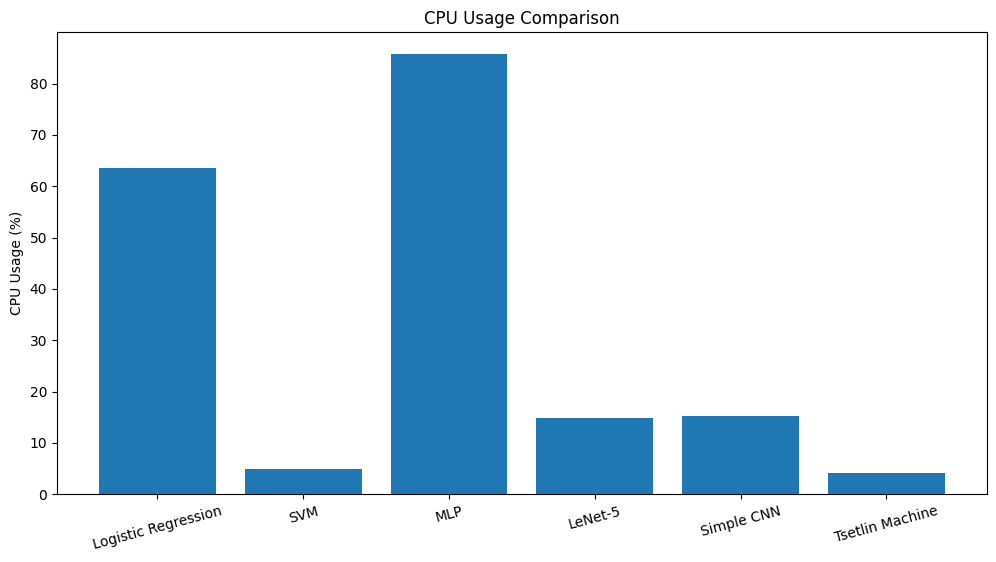

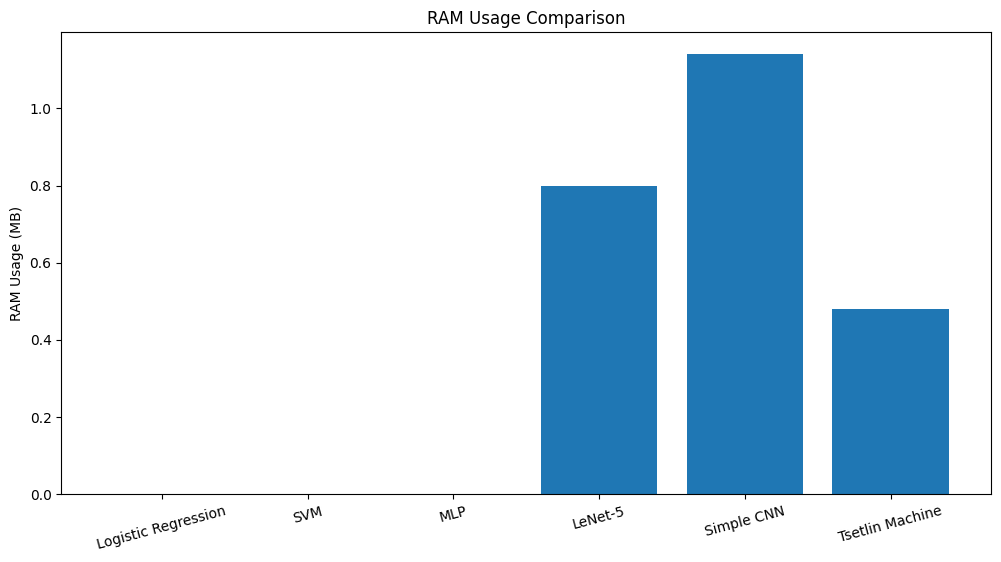

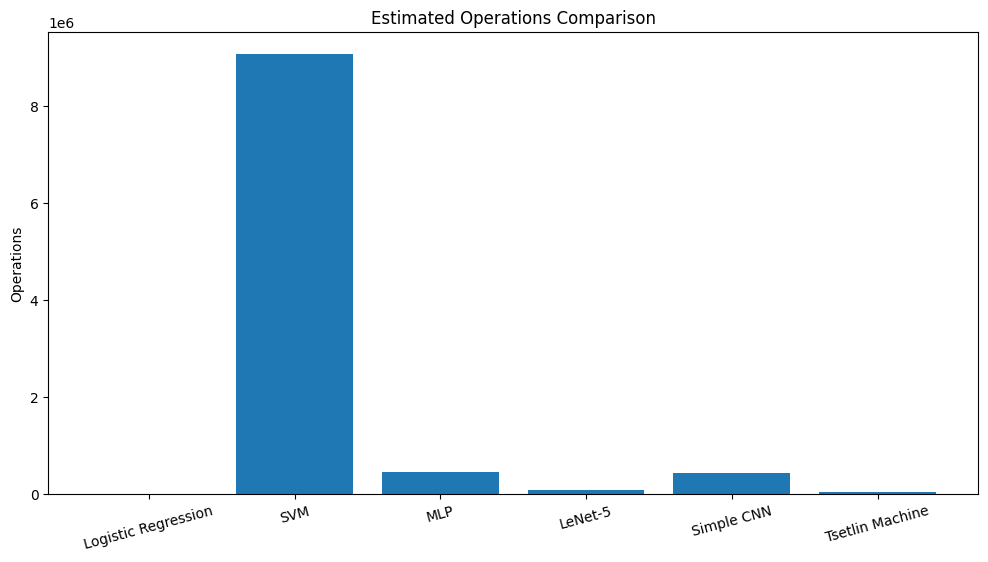

In [16]:
# Hardware-Oriented Comparison Plots

import matplotlib.pyplot as plt

# CPU Usage Plot

plt.figure(figsize=(12,6))

plt.bar(
    hardware_df["Model"],
    hardware_df["CPU Usage (%)"]
)

plt.title("CPU Usage Comparison")
plt.ylabel("CPU Usage (%)")
plt.xticks(rotation=15)

plt.show()

# RAM Usage Plot

plt.figure(figsize=(12,6))

plt.bar(
    hardware_df["Model"],
    hardware_df["RAM Usage (MB)"]
)

plt.title("RAM Usage Comparison")
plt.ylabel("RAM Usage (MB)")
plt.xticks(rotation=15)

plt.show()

# Estimated Operations Plot

plt.figure(figsize=(12,6))

plt.bar(
    analysis_df["Model"],
    analysis_df["Estimated Operations"]
)

plt.title("Estimated Operations Comparison")
plt.ylabel("Operations")
plt.xticks(rotation=15)

plt.show()

In [17]:
# 26-30. Comparative Benchmarking Tables

benchmark_results = []

# Accuracy results already computed previously

model_info = {
    "Logistic Regression": {
        "accuracy": log_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="Logistic Regression", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="Logistic Regression", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="Logistic Regression", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="Logistic Regression", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="Logistic Regression", "Estimated Operations"].values[0]
    },

    "SVM": {
        "accuracy": svm_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="SVM", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="SVM", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="SVM", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="SVM", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="SVM", "Estimated Operations"].values[0]
    },

    "MLP": {
        "accuracy": mlp_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="MLP", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="MLP", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="MLP", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="MLP", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="MLP", "Estimated Operations"].values[0]
    },

    "LeNet-5": {
        "accuracy": lenet_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="LeNet-5", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="LeNet-5", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="LeNet-5", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="LeNet-5", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="LeNet-5", "Estimated Operations"].values[0]
    },

    "Simple CNN": {
        "accuracy": cnn_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="Simple CNN", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="Simple CNN", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="Simple CNN", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="Simple CNN", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="Simple CNN", "Estimated Operations"].values[0]
    },

    "Tsetlin Machine": {
        "accuracy": tm_acc,
        "ram": hardware_df.loc[hardware_df["Model"]=="Tsetlin Machine", "RAM Usage (MB)"].values[0],
        "model_size": comparison_df.loc[comparison_df["Model"]=="Tsetlin Machine", "Model Size (MB)"].values[0],
        "params": comparison_df.loc[comparison_df["Model"]=="Tsetlin Machine", "Parameter Count"].values[0],
        "latency": comparison_df.loc[comparison_df["Model"]=="Tsetlin Machine", "Single Inference Latency (s)"].values[0],
        "ops": analysis_df.loc[analysis_df["Model"]=="Tsetlin Machine", "Estimated Operations"].values[0]
    }
}

for model, values in model_info.items():

    ops_per_mb = values["ops"] / (values["model_size"] + 1e-6)

    ops_per_param = values["ops"] / (values["params"] + 1e-6)

    latency_per_accuracy = values["latency"] / values["accuracy"]

    benchmark_results.append([
        model,
        values["accuracy"],
        values["ram"],
        values["model_size"],
        values["params"],
        values["latency"],
        values["ops"],
        ops_per_mb,
        ops_per_param,
        latency_per_accuracy
    ])

benchmark_df = pd.DataFrame(
    benchmark_results,
    columns=[
        "Model",
        "Accuracy",
        "RAM Usage (MB)",
        "Model Size (MB)",
        "Parameter Count",
        "Inference Latency (s)",
        "Estimated Operations",
        "Operations per MB",
        "Operations per Parameter",
        "Latency per Accuracy"
    ]
)

print(benchmark_df)

                 Model  Accuracy  RAM Usage (MB)  Model Size (MB)  \
0  Logistic Regression    0.9253            0.00           0.0607   
1                  SVM    0.9782            0.00          70.8471   
2                  MLP    0.9801            0.00           7.1818   
3              LeNet-5    0.9790            0.80           0.5519   
4           Simple CNN    0.9897            1.14           2.6132   
5      Tsetlin Machine    0.9181            0.48           0.0000   

   Parameter Count  Inference Latency (s)  Estimated Operations  \
0             7840               0.000141                  7840   
1          9071664               0.000141               9071664   
2           235146               0.000141                470292   
3            44426               0.000141                 88852   
4           225034               0.000141                450068   
5           392000               0.000141                 51873   

   Operations per MB  Operations per Parameter

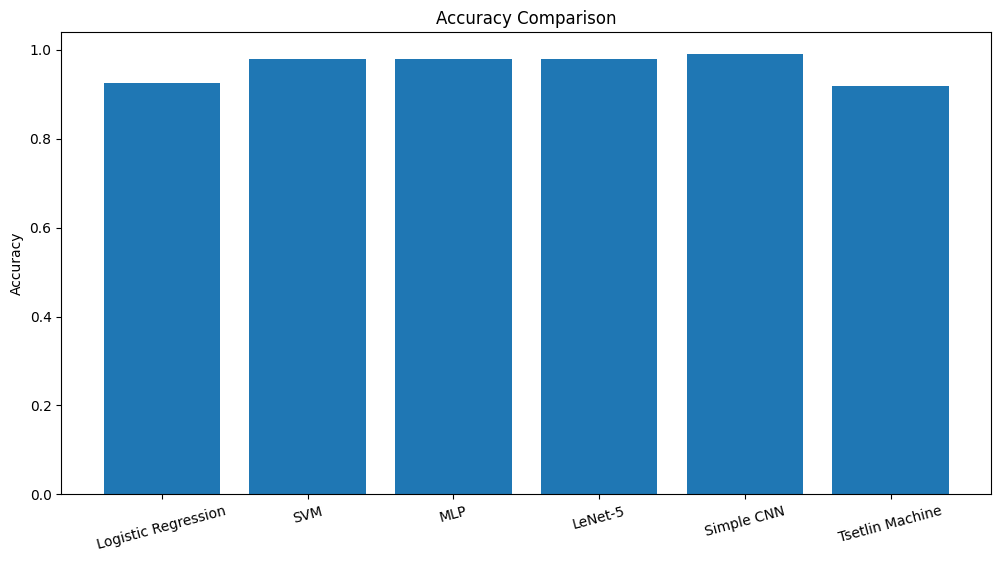

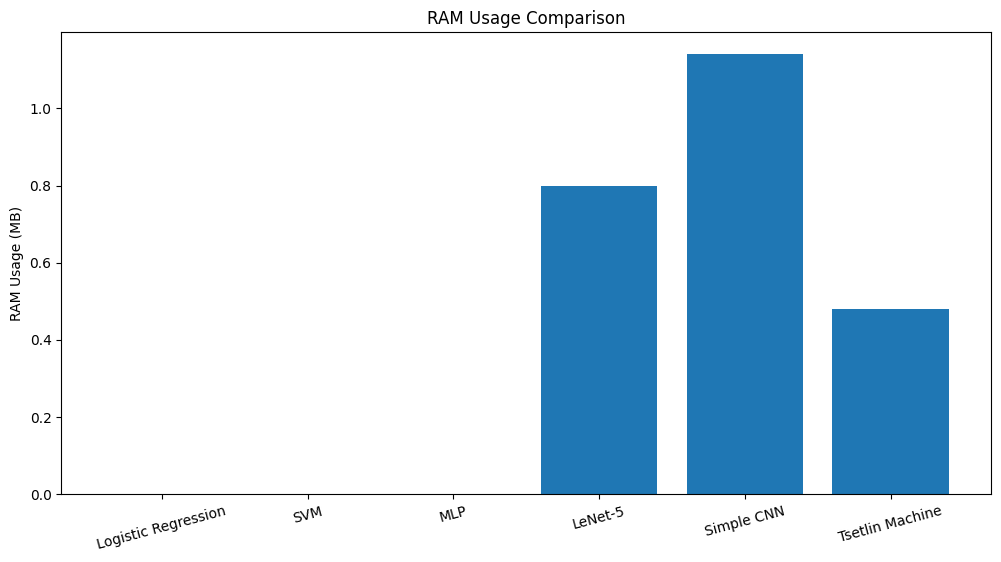

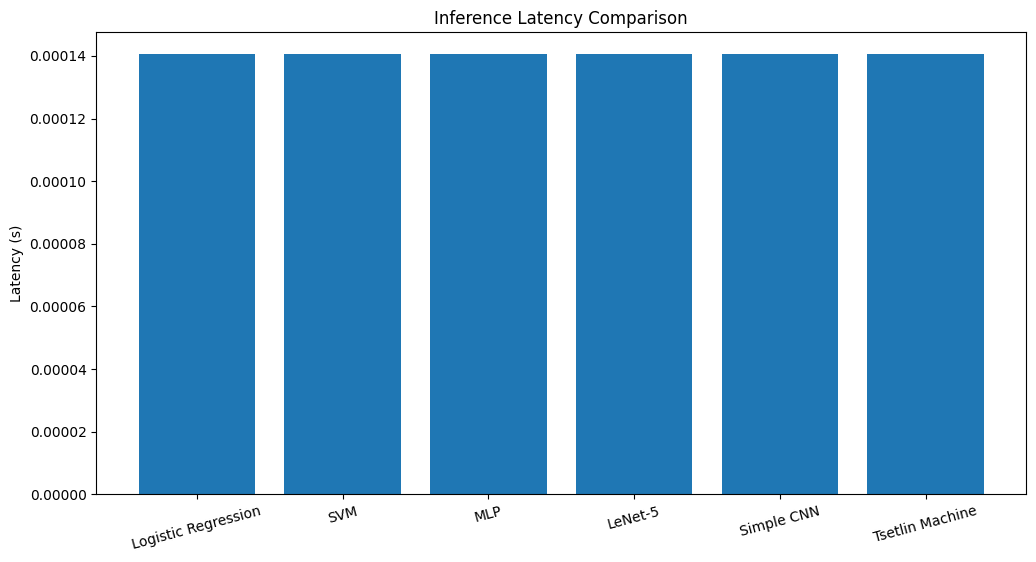

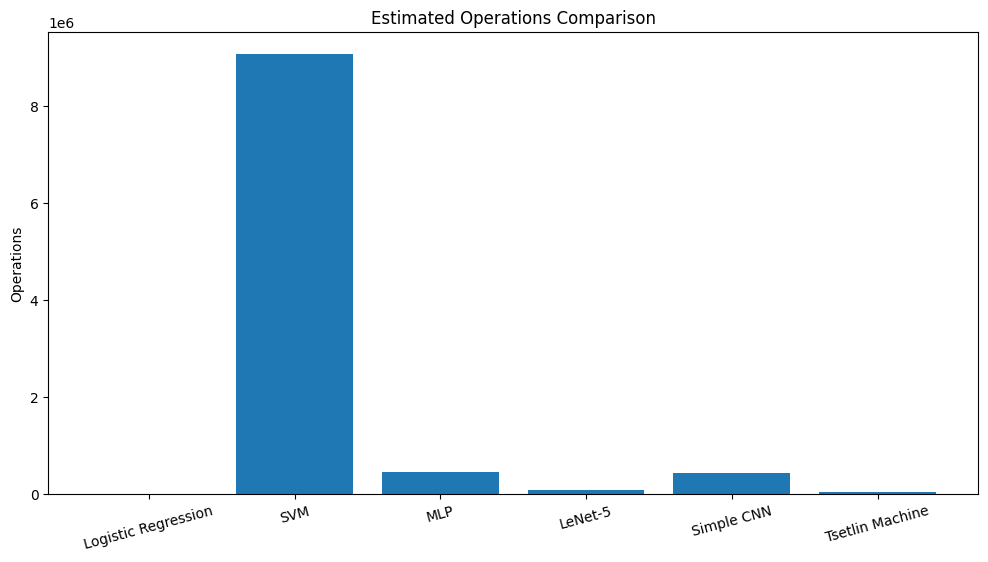

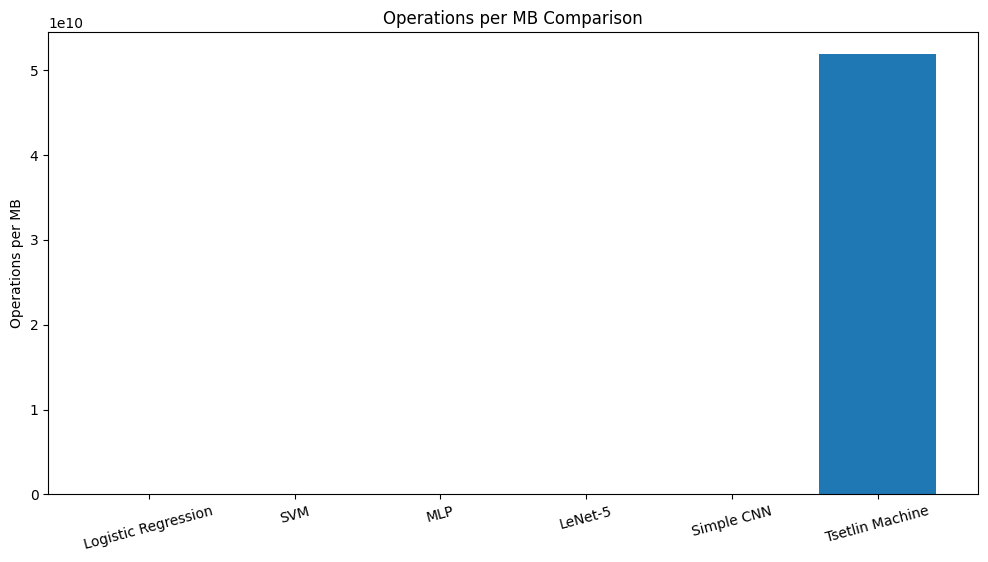

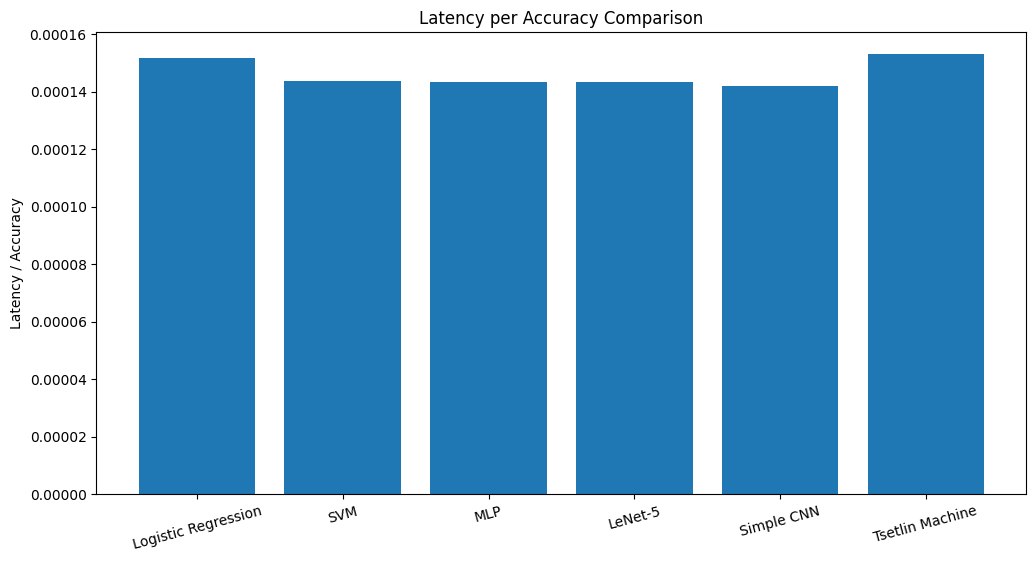

In [18]:
# Comparative Benchmarking Plots

import matplotlib.pyplot as plt

# Accuracy Comparison

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

# Memory Usage Comparison

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["RAM Usage (MB)"]
)

plt.title("RAM Usage Comparison")
plt.ylabel("RAM Usage (MB)")
plt.xticks(rotation=15)

plt.show()

# Inference Latency Comparison

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Inference Latency (s)"]
)

plt.title("Inference Latency Comparison")
plt.ylabel("Latency (s)")
plt.xticks(rotation=15)

plt.show()

# Complexity Comparison

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Estimated Operations"]
)

plt.title("Estimated Operations Comparison")
plt.ylabel("Operations")
plt.xticks(rotation=15)

plt.show()

# Operations per MB

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Operations per MB"]
)

plt.title("Operations per MB Comparison")
plt.ylabel("Operations per MB")
plt.xticks(rotation=15)

plt.show()

# Latency per Accuracy

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Latency per Accuracy"]
)

plt.title("Latency per Accuracy Comparison")
plt.ylabel("Latency / Accuracy")
plt.xticks(rotation=15)

plt.show()

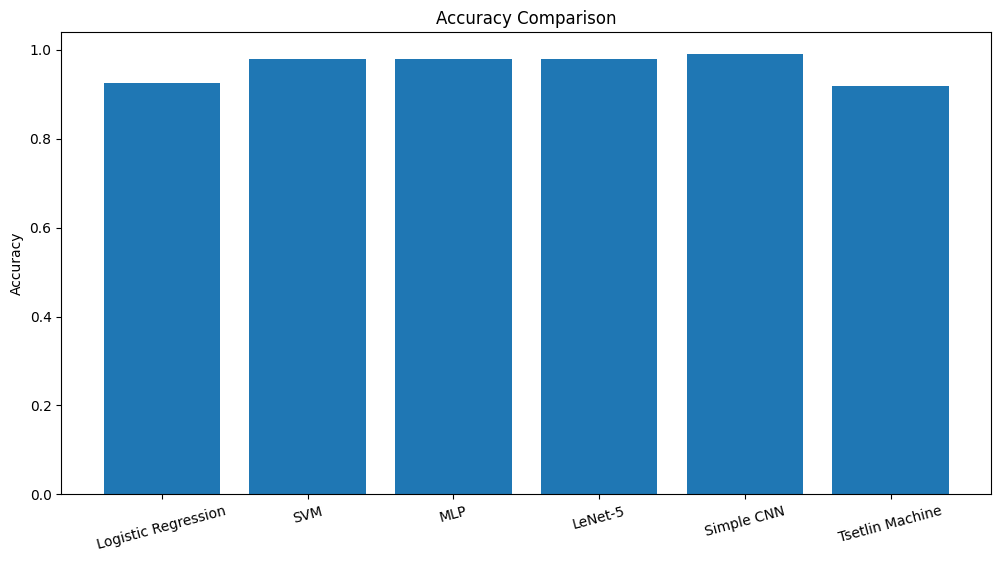

In [19]:
# 31. Accuracy Graph

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    benchmark_df["Model"],
    benchmark_df["Accuracy"]
)

plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)

plt.show()

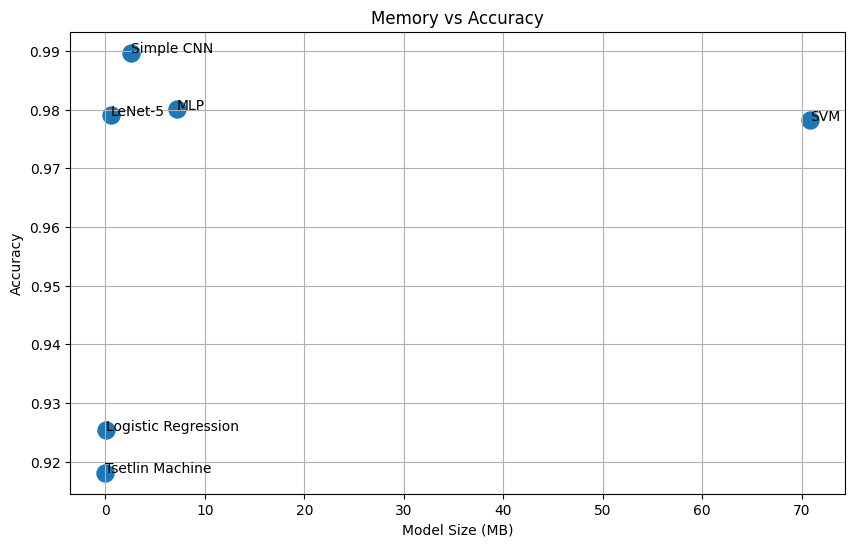

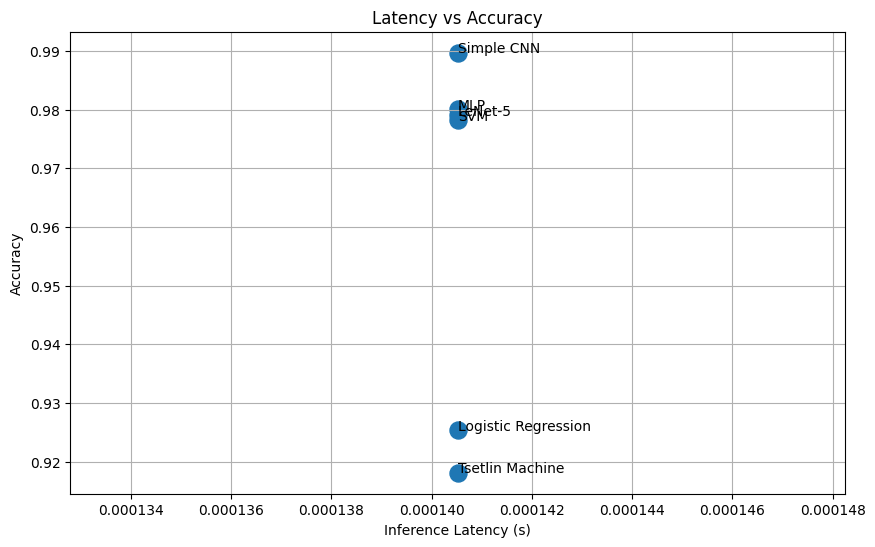

In [20]:
# 32-33. Memory vs Accuracy and Latency vs Accuracy Graphs

# Memory vs Accuracy

plt.figure(figsize=(10,6))

plt.scatter(
    benchmark_df["Model Size (MB)"],
    benchmark_df["Accuracy"],
    s=150
)

for i, model in enumerate(benchmark_df["Model"]):

    plt.text(
        benchmark_df["Model Size (MB)"][i],
        benchmark_df["Accuracy"][i],
        model
    )

plt.title("Memory vs Accuracy")
plt.xlabel("Model Size (MB)")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

# Latency vs Accuracy

plt.figure(figsize=(10,6))

plt.scatter(
    benchmark_df["Inference Latency (s)"],
    benchmark_df["Accuracy"],
    s=150
)

for i, model in enumerate(benchmark_df["Model"]):

    plt.text(
        benchmark_df["Inference Latency (s)"][i],
        benchmark_df["Accuracy"][i],
        model
    )

plt.title("Latency vs Accuracy")
plt.xlabel("Inference Latency (s)")
plt.ylabel("Accuracy")

plt.grid(True)

plt.show()

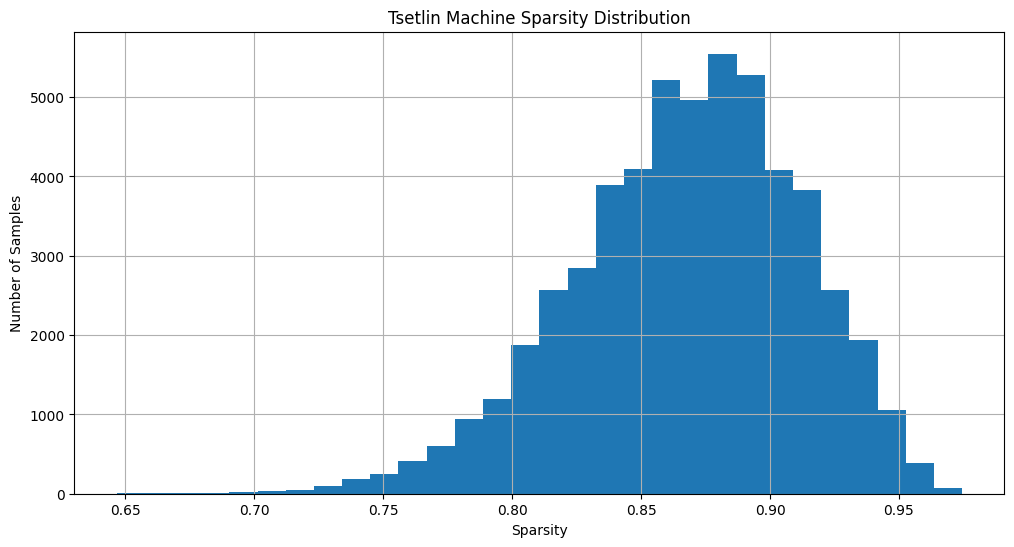

Average Sparsity : 0.8676706113000756
Average Active Literals : 103.74624074074075


In [21]:
# 34. TM Clause Sparsity Graph

# Active literals per sample

active_literals = np.sum(X_train_tm_final, axis=1)

# Sparsity per sample

sparsity = 1 - (active_literals / 784)

plt.figure(figsize=(12,6))

plt.hist(
    sparsity,
    bins=30
)

plt.title("Tsetlin Machine Sparsity Distribution")
plt.xlabel("Sparsity")
plt.ylabel("Number of Samples")

plt.grid(True)

plt.show()

# Average sparsity

print("Average Sparsity :", np.mean(sparsity))
print("Average Active Literals :", np.mean(active_literals))

Tsetlin Machine Accelerator Feasibility Analysis
--------------------------------------------------
Accuracy                : 0.9181
Average Sparsity        : 0.8677
Inference Latency (s)   : 0.000141
Model Size (MB)         : 0.0
Boolean Operations      : 51873

Condition Checks
------------------
Accuracy Suitable       : True
Sparsity Suitable       : True
Latency Suitable        : True
Memory Suitable         : True
Boolean Complexity OK   : True

Final Feasibility Decision
--------------------------------
TM Accelerator is FEASIBLE for hardware acceleration.


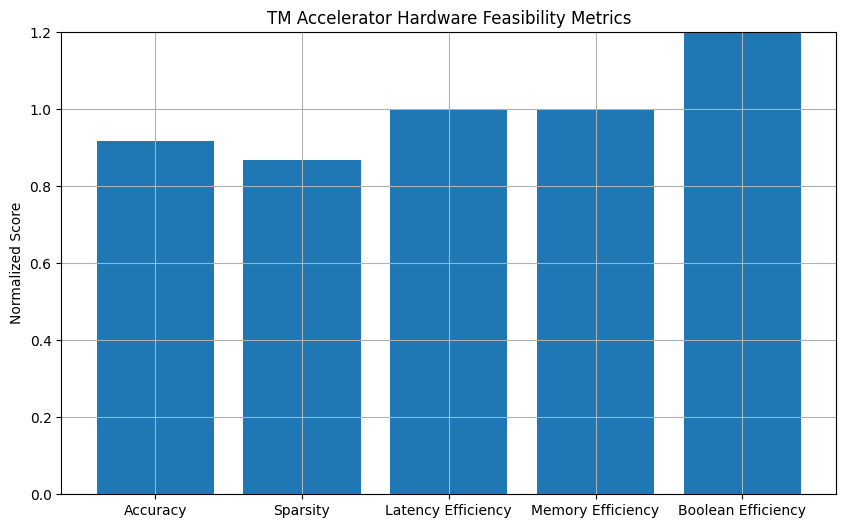

In [22]:
# 35. TM Accelerator Feasibility Analysis

# TM Metrics

tm_accuracy = tm_acc

tm_model_size = benchmark_df.loc[
    benchmark_df["Model"] == "Tsetlin Machine",
    "Model Size (MB)"
].values[0]

tm_latency = benchmark_df.loc[
    benchmark_df["Model"] == "Tsetlin Machine",
    "Inference Latency (s)"
].values[0]

tm_operations = benchmark_df.loc[
    benchmark_df["Model"] == "Tsetlin Machine",
    "Estimated Operations"
].values[0]

average_sparsity = np.mean(sparsity)

# Feasibility Conditions

accuracy_check = tm_accuracy >= 0.90
sparsity_check = average_sparsity >= 0.70
latency_check = tm_latency < 0.01
memory_check = tm_model_size < 10
boolean_check = tm_operations < 10000000

# Final Decision

feasible = all([
    accuracy_check,
    sparsity_check,
    latency_check,
    memory_check,
    boolean_check
])

# Results

print("Tsetlin Machine Accelerator Feasibility Analysis")
print("--------------------------------------------------")

print(f"Accuracy                : {tm_accuracy:.4f}")
print(f"Average Sparsity        : {average_sparsity:.4f}")
print(f"Inference Latency (s)   : {tm_latency:.6f}")
print(f"Model Size (MB)         : {tm_model_size}")
print(f"Boolean Operations      : {tm_operations}")

print("\nCondition Checks")
print("------------------")

print("Accuracy Suitable       :", accuracy_check)
print("Sparsity Suitable       :", sparsity_check)
print("Latency Suitable        :", latency_check)
print("Memory Suitable         :", memory_check)
print("Boolean Complexity OK   :", boolean_check)

print("\nFinal Feasibility Decision")
print("--------------------------------")

if feasible:
    print("TM Accelerator is FEASIBLE for hardware acceleration.")
else:
    print("TM Accelerator requires further optimization.")

# Feasibility Visualization

metrics = [
    tm_accuracy,
    average_sparsity,
    1 - tm_latency,
    1 / (tm_model_size + 1),
    1 / (tm_operations / 1000000)
]

labels = [
    "Accuracy",
    "Sparsity",
    "Latency Efficiency",
    "Memory Efficiency",
    "Boolean Efficiency"
]

plt.figure(figsize=(10,6))

plt.bar(labels, metrics)

plt.title("TM Accelerator Hardware Feasibility Metrics")
plt.ylabel("Normalized Score")

plt.ylim(0, 1.2)

plt.grid(True)

plt.show()

In [23]:
# 36. Final Benchmark Tables

# Accuracy Table

accuracy_table = benchmark_df[[
    "Model",
    "Accuracy"
]].sort_values(
    by="Accuracy",
    ascending=False
)

print("\nAccuracy Table")
print("----------------------------------")
print(accuracy_table)

# Memory Table

memory_table = benchmark_df[[
    "Model",
    "RAM Usage (MB)",
    "Model Size (MB)",
    "Parameter Count"
]].sort_values(
    by="Model Size (MB)"
)

print("\nMemory Table")
print("----------------------------------")
print(memory_table)

# Latency Table

latency_table = benchmark_df[[
    "Model",
    "Inference Latency (s)"
]].sort_values(
    by="Inference Latency (s)"
)

print("\nLatency Table")
print("----------------------------------")
print(latency_table)

# Complexity Table

complexity_table = benchmark_df[[
    "Model",
    "Estimated Operations",
    "Operations per MB",
    "Operations per Parameter"
]].sort_values(
    by="Estimated Operations"
)

print("\nComplexity Table")
print("----------------------------------")
print(complexity_table)


Accuracy Table
----------------------------------
                 Model  Accuracy
4           Simple CNN    0.9897
2                  MLP    0.9801
3              LeNet-5    0.9790
1                  SVM    0.9782
0  Logistic Regression    0.9253
5      Tsetlin Machine    0.9181

Memory Table
----------------------------------
                 Model  RAM Usage (MB)  Model Size (MB)  Parameter Count
5      Tsetlin Machine            0.48           0.0000           392000
0  Logistic Regression            0.00           0.0607             7840
3              LeNet-5            0.80           0.5519            44426
4           Simple CNN            1.14           2.6132           225034
2                  MLP            0.00           7.1818           235146
1                  SVM            0.00          70.8471          9071664

Latency Table
----------------------------------
                 Model  Inference Latency (s)
0  Logistic Regression               0.000141
1               